In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-5 ,5,300)

relu= lambda x:np.maximum(0,x)
sigmoid = lambda x:1/(1+np.exp(-x))
tanh_fn = np.tanh
leaky = lambda x:np.where(x>0 , x, 0.01 *x)

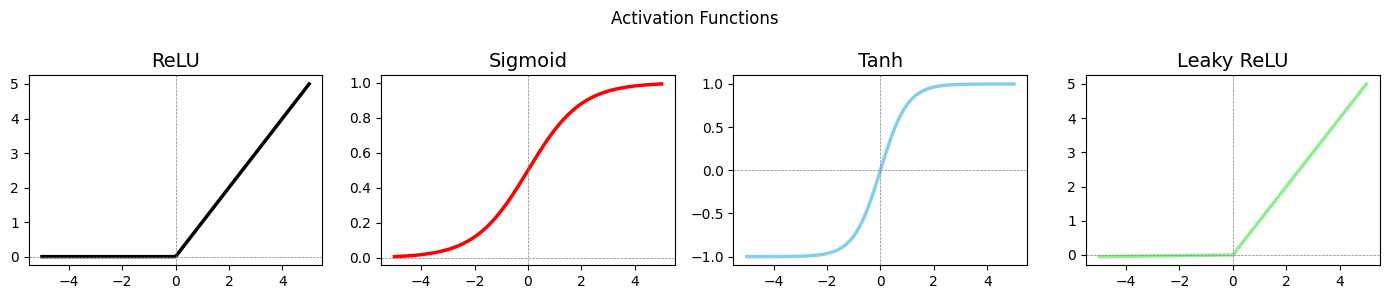

In [ ]:
fig ,axes=plt.subplots(1,4, figsize=(14,3))
fns = [relu , sigmoid, tanh_fn,leaky]
names = ['ReLU','Sigmoid', 'Tanh','Leaky ReLU']
cols=['black' ,'red','skyblue','lightgreen',]

for ax, fn ,name, col in zip(axes ,fns,names , cols):
  ax.plot(x,fn(x),color=col,linewidth=2.5)
  ax.axhline(0, color='gray', lw=0.5,ls='--')
  ax.axvline(0, color='gray', lw=0.5,ls='--')
  ax.set_title(name,fontsize=14)
plt.suptitle('Activation Functions',fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [ ]:
(x_train ,y_train) ,( x_test ,y_test)= keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f'Train:{x_train.shape} Test:{x_test.shape}')

model= keras.Sequential([
    keras.Input(shape=(784, )),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),


    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')

])


model.summary()

Train:(60000, 784) Test:(10000, 784)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau

early_stop = EarlyStopping(monitor = 'val_loss', patience=5,restore_best_weights = True, verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=6,verbose=1)

In [ ]:
history = model.fit(
    x_train ,y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8560 - loss: 0.4748 - val_accuracy: 0.9605 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9382 - loss: 0.2101 - val_accuracy: 0.9700 - val_loss: 0.1043 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9527 - loss: 0.1591 - val_accuracy: 0.9742 - val_loss: 0.0855 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9599 - loss: 0.1320 - val_accuracy: 0.9735 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9653 - loss: 0.1138 - val_accuracy: 0.9788 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9701 - loss: 0.0991 - val_accuracy: 0.9797 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.0906 - 

Test Accuracy: 97.89%
Test Loss: 0.0699


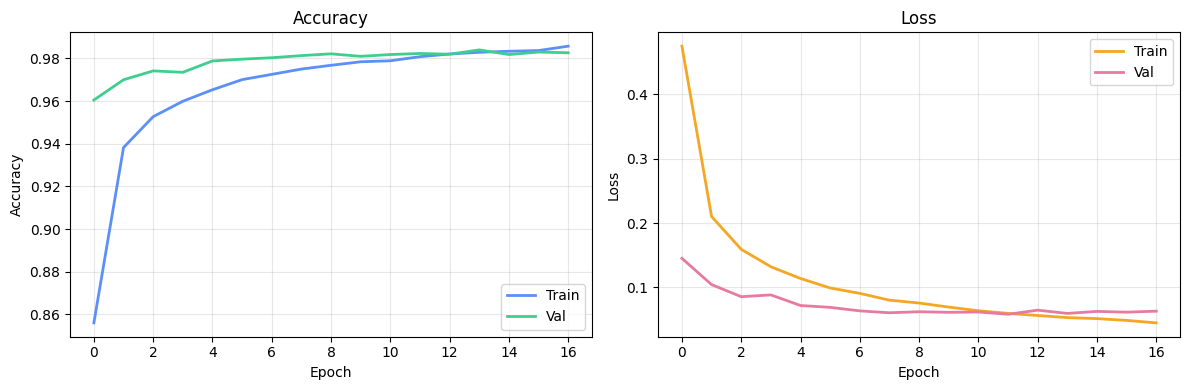

In [ ]:
# ■■ Step 7: Evaluate on test set ■■■■■■■■■■■■■■■■■■■■■■■■■■■■
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%') # expect 97-98%
print(f'Test Loss: {test_loss:.4f}')

# ■■ Step 8: Plot training curves ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', color='#5B8FF9', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val', color='#3ECF8E', lw=2)
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', color='#F5A623', lw=2)
ax2.plot(history.history['val_loss'], label='Val', color='#E879A0', lw=2)
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

LAB on MNIST classifier:-


Build, train, and evaluate a neural network on the full MNIST dataset. Visualise predictions, inspect the confusion matrix, examine misclassified digits, and experiment with different architectures to understand how design choices affect accuracy.




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


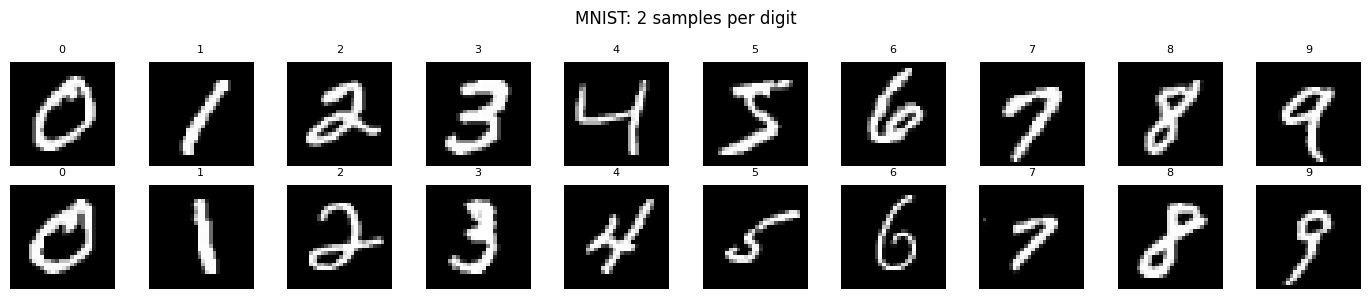

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
fig, axes = plt.subplots(2, 10, figsize=(14, 3))


for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()


def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()

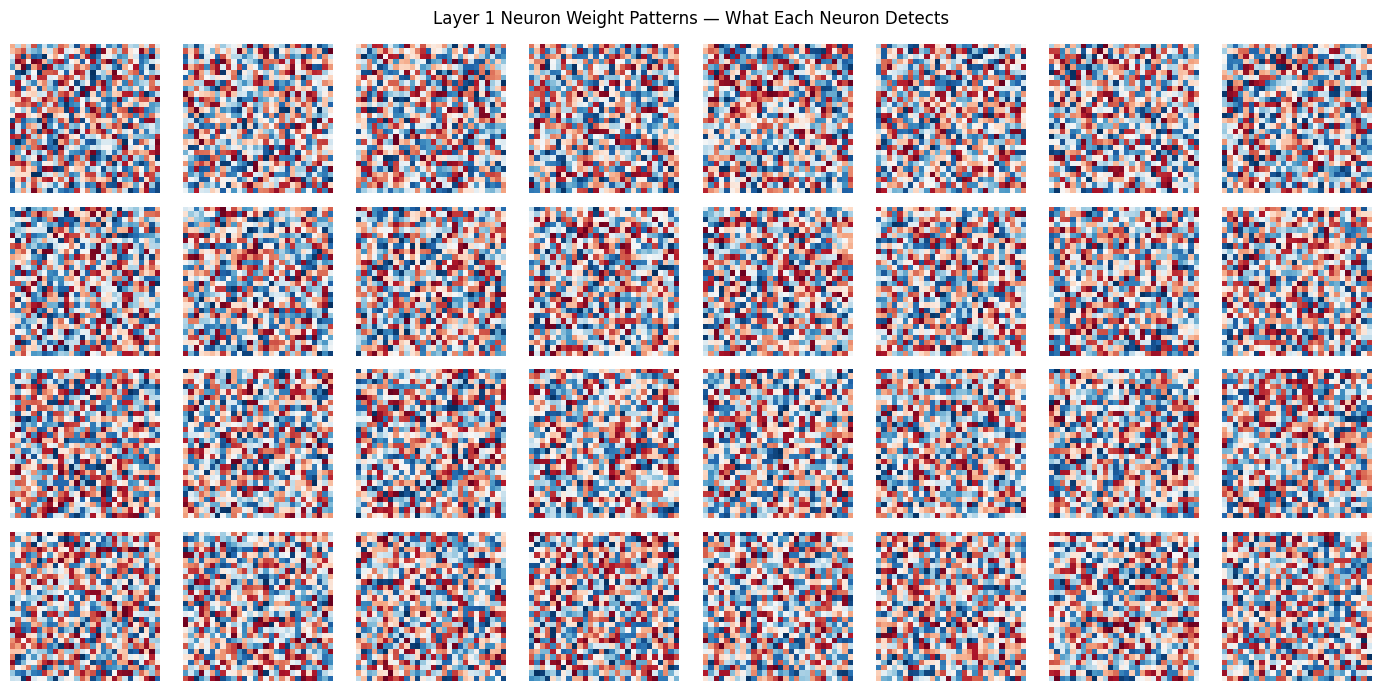

In [ ]:
# ■■ Each Layer 1 neuron has 784 weights
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()